# Problem 1 — Elliptic BVP

Solve the nonlinear BVP on $\Omega = [0,1]^2$:
$$
\begin{cases}
\nabla^2 u - u^4 = 0, & x \in \Omega, \\
u(x) = 1, & x \in \partial\Omega.
\end{cases}
$$

The domain is discretised on an $N\times N$ interior grid with spacing $h = 1/N$.
The 5-point Laplacian stencil is
$$
\Delta_h u_{i,j} = \frac{u_{i-1,j}+u_{i+1,j}+u_{i,j-1}+u_{i,j+1}-4u_{i,j}}{h^2}.
$$

`Laplace_5(u)` implements this: it pads the $N\times N$ interior array to $(N+2)\times(N+2)$ with the boundary value $1$, applies the stencil, and returns $N\times N$.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
try:
    jax.config.update('jax_platform_name', 'gpu')
    _ = jax.devices('gpu')
    print("Using GPU:", jax.devices('gpu'), flush=True)
except RuntimeError:
    jax.config.update('jax_platform_name', 'cpu')
    print("GPU not available, using CPU.", flush=True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from Problem1 import (
    PS4_Problem1,
    Laplace_5, F_residual,
    J_matvec, J_diagonal, get_jacobian_matrix,
    get_L2_error, get_inf_error,
)

Using GPU: [CudaDevice(id=0), CudaDevice(id=1)]
2
[CudaDevice(id=0), CudaDevice(id=1)]


## (a) Reformulation as a root-finding problem

Define the residual vector
$$
F(u)_{i,j} = \Delta_h u_{i,j} - u_{i,j}^4 = 0, \quad 1 \le i,j \le N,
$$
so the BVP becomes the $N^2$-dimensional root-finding problem $F(u) = 0$.

**Newton-Raphson iteration:**
$$
J(u^{(k)})\,\delta u = F(u^{(k)}), \qquad u^{(k+1)} = u^{(k)} - \delta u,
$$
where the Jacobian is
$$
J(u) = \frac{\partial F}{\partial u} = \Delta_h - \operatorname{diag}(4u^3).
$$

$\Delta_h$ with zero-boundary conditions is negative semi-definite, and $-\operatorname{diag}(4u^3)$ is negative definite for $u>0$, so $J$ is negative definite — the system $J\,\delta u = F$ has a unique solution.

**Initial guess:** $u^{(0)} = 1$ everywhere (the boundary value).

**Convergence criterion:** $\|\delta u\|_\infty < \tau$.

### Verify Jacobian against finite differences

In [2]:
N_test = 8
u_test = jnp.ones((N_test, N_test), dtype=jnp.float64) * 0.9

# Full Jacobian via jacfwd
J_full = get_jacobian_matrix(u_test)   # (N², N²)
print(f"Jacobian shape: {J_full.shape}")

# Check one column: J @ e_k  vs  J_matvec(u, e_k)
k = N_test * (N_test // 2) + N_test // 2   # centre point
e_k = jnp.zeros(N_test**2).at[k].set(1.0).reshape(N_test, N_test)
J_matvec(u_test, e_k, check=True)


jac_col_full   = J_full[:, k]
jac_col_matvec = J_matvec(u_test, e_k).reshape(-1)
print(f"Max diff (jacfwd vs J_matvec): {float(jnp.max(jnp.abs(jac_col_full - jac_col_matvec))):.3e}")

Jacobian shape: (64, 64)
Close check: max abs difference = 0.0
Max diff (jacfwd vs J_matvec): 0.000e+00


## (b) Direct solve with full Jacobian  ($N = 64$)

Each Newton step solves $J(u^{(k)})\,\delta u = F(u^{(k)})$ exactly using
`jnp.linalg.solve` (LU factorisation of the dense $N^2 \times N^2$ matrix
obtained from `jax.jacfwd`).

For $N=64$ the matrix is $4096\times 4096 \approx 128$~MB — manageable.

In [3]:
p_b = PS4_Problem1(N=64)
u_direct = p_b.solve_direct(tol=1e-10, max_iter=50)

Initialized PS4_Problem1 with N=64, h=0.015625
  Newton iter 1: ‖Δu‖_∞ = 6.171e-02
  Newton iter 2: ‖Δu‖_∞ = 8.904e-04
  Newton iter 3: ‖Δu‖_∞ = 1.423e-07
  Newton iter 4: ‖Δu‖_∞ = 4.951e-15
Newton (direct) converged in 4 iterations.


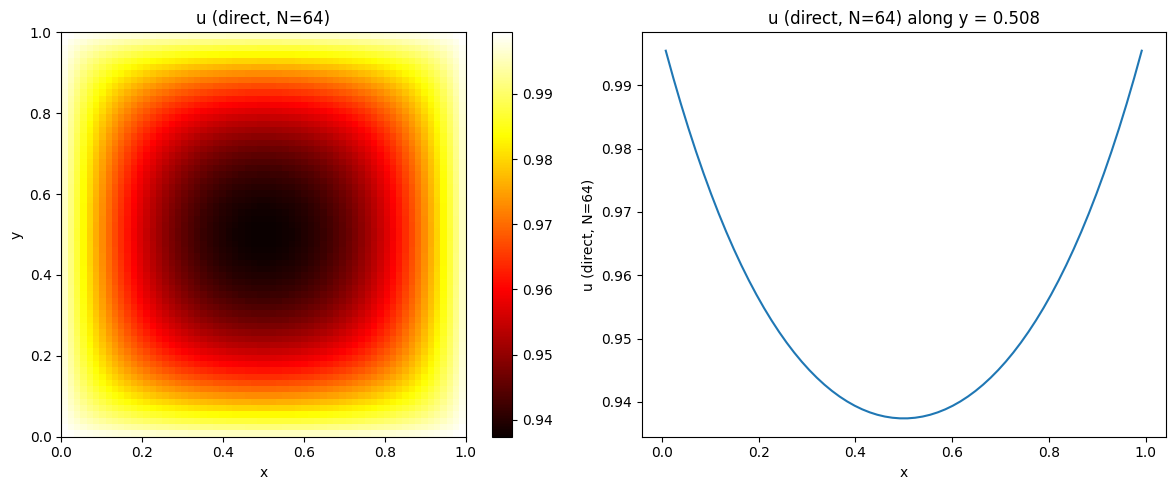

In [4]:
p_b.plot(u_direct, name='u (direct, N=64)')

In [5]:
res_direct = float(jnp.max(jnp.abs(F_residual(u_direct))))
print(f"Final residual ‖F(u)‖_∞ = {res_direct:.3e}")
print(f"Solution range: [{float(jnp.min(u_direct)):.6f}, {float(jnp.max(u_direct)):.6f}]")

Final residual ‖F(u)‖_∞ = 4.681e-12
Solution range: [0.937400, 0.999433]


## (c) Jacobi-Newton (matrix-free)  +  convergence study

Instead of forming the full Jacobian, each Newton step solves $J(u)\,\delta u = F(u)$
by **Jacobi iteration** using only `J_matvec` and `J_diagonal`.

Since $J$ is strictly diagonally dominant for $u>0$ (off-diagonal sum $= 4/h^2$,
diagonal $= -4/h^2 - 4u^3$, so $|J_{ii}| > \sum_{j\ne i}|J_{ij}|$), Jacobi
converges unconditionally.

**Convergence study:** solve at $N = 128$, $256$, $512$ and compare against
$N=512$ (ground truth) to verify second-order accuracy.

In [6]:
# Cross-check: Jacobi vs direct for N=64
# For N=64, the default jacobi_tol = 0.19/64² ≈ 4.6e-5 is tuned for large N.
# For a cross-check we want full accuracy, so tighten both tolerances.
p_c64 = PS4_Problem1(N=64)
u_jacobi_64 = p_c64.solve_jacobi(newton_tol=1e-8, jacobi_tol=1e-10, max_jacobi=50000)
print(f"Max diff vs direct: {float(get_inf_error(u_jacobi_64, u_direct)):.3e}")

Initialized PS4_Problem1 with N=64, h=0.015625
  Newton iter 1: ‖Δu‖_∞ = 6.171e-02
  Newton iter 2: ‖Δu‖_∞ = 8.904e-04
  Newton iter 3: ‖Δu‖_∞ = 1.427e-07
  Newton iter 4: ‖Δu‖_∞ = 1.995e-10
Newton (Jacobi) converged in 4 iterations.
Max diff vs direct: 7.181e-08


In [7]:
# Convergence study: N = 32, 64, 128, 256, 512
# Use direct solver for small N (fast, exact), Jacobi for large N
Ns = [64, 128, 256, 512]
solutions = {}

for N in Ns:
    print(f"\n── Solving N={N} ──")
    p = PS4_Problem1(N=N)
    if N <= 64:
        solutions[N] = p.solve_direct(tol=1e-10, max_iter=50)
    else:
        solutions[N] = p.solve_jacobi(newton_tol=1e-5)


── Solving N=64 ──
Initialized PS4_Problem1 with N=64, h=0.015625
  Newton iter 1: ‖Δu‖_∞ = 6.171e-02
  Newton iter 2: ‖Δu‖_∞ = 8.904e-04
  Newton iter 3: ‖Δu‖_∞ = 1.423e-07
  Newton iter 4: ‖Δu‖_∞ = 4.951e-15
Newton (direct) converged in 4 iterations.

── Solving N=128 ──
Initialized PS4_Problem1 with N=128, h=0.007812
  Newton iter 1: ‖Δu‖_∞ = 2.680e-02
  Newton iter 2: ‖Δu‖_∞ = 2.325e-04
  Newton iter 3: ‖Δu‖_∞ = 2.318e-05
  Newton iter 4: ‖Δu‖_∞ = 2.317e-05
  Newton iter 5: ‖Δu‖_∞ = 2.316e-05
  Newton iter 6: ‖Δu‖_∞ = 2.314e-05
  Newton iter 7: ‖Δu‖_∞ = 2.313e-05
  Newton iter 8: ‖Δu‖_∞ = 2.312e-05
  Newton iter 9: ‖Δu‖_∞ = 2.310e-05
  Newton iter 10: ‖Δu‖_∞ = 2.309e-05
  Newton iter 11: ‖Δu‖_∞ = 2.308e-05
  Newton iter 12: ‖Δu‖_∞ = 2.307e-05
  Newton iter 13: ‖Δu‖_∞ = 2.305e-05
  Newton iter 14: ‖Δu‖_∞ = 2.304e-05
  Newton iter 15: ‖Δu‖_∞ = 2.303e-05
  Newton iter 16: ‖Δu‖_∞ = 2.302e-05
  Newton iter 17: ‖Δu‖_∞ = 2.300e-05
  Newton iter 18: ‖Δu‖_∞ = 2.299e-05
  Newton iter 19: ‖Δ

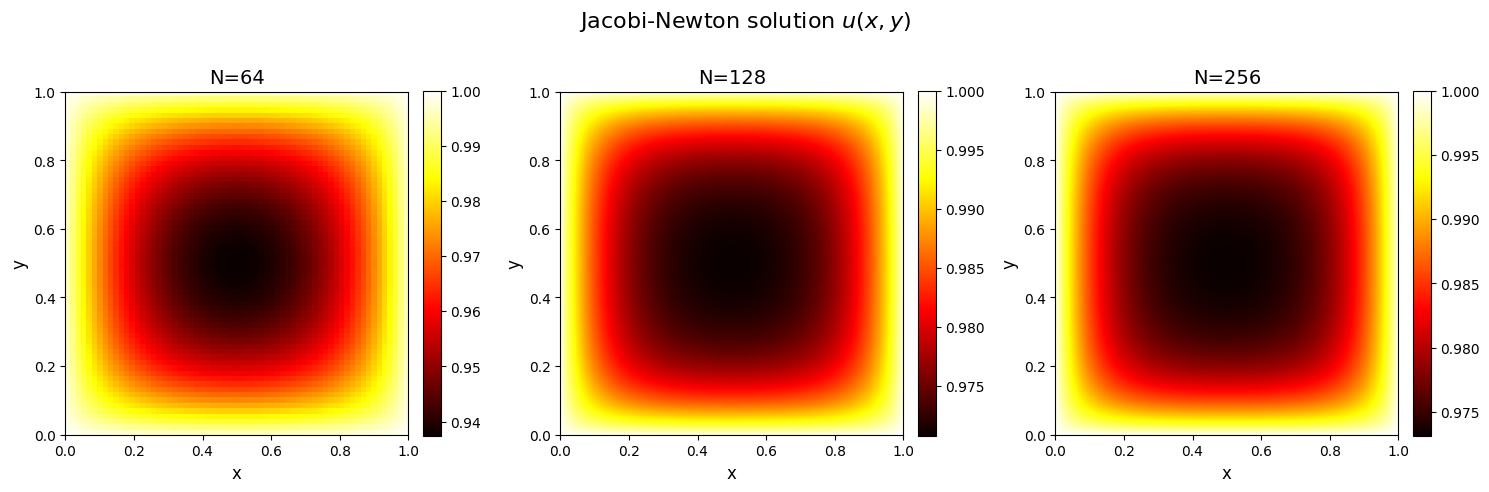

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, N in zip(axes, Ns):
    u_np = jax.device_get(solutions[N])
    im = ax.imshow(u_np.T, origin='lower', extent=[0, 1, 0, 1],
                   cmap='hot', vmin=u_np.min(), vmax=1.0)
    ax.set_title(f'N={N}', fontsize=14)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('Jacobi-Newton solution $u(x,y)$', fontsize=16)
plt.tight_layout()
plt.savefig('p1c_solutions.png', dpi=150)
plt.show()

In [9]:
# Use N=512 as ground truth; subsample to each coarser grid (stride = 512 // N)
Ns_study = [64, 128, 256]
u512 = solutions[512]

hs      = np.array([1.0 / (N + 1) for N in Ns_study])
err_L2  = []
err_inf = []

for N in Ns_study:
    stride = 512 // N
    u512_on_N = u512[::stride, ::stride]
    err_L2.append(float(get_L2_error(solutions[N], u512_on_N)))
    err_inf.append(float(get_inf_error(solutions[N], u512_on_N)))

err_L2  = np.array(err_L2)
err_inf = np.array(err_inf)

# Power-law fit over all 4 points
coeffs_L2  = np.polyfit(np.log(hs), np.log(err_L2),  1)
coeffs_inf = np.polyfit(np.log(hs), np.log(err_inf), 1)

print(f"{'N':>6}  {'h':>10}  {'L2 error':>12}  {'inf error':>12}")
for N, h, eL2, einf in zip(Ns_study, hs, err_L2, err_inf):
    print(f"{N:>6}  {h:>10.4e}  {eL2:>12.4e}  {einf:>12.4e}")
print()
print(f"L2  order (polyfit, 4 pts) = {coeffs_L2[0]:.2f}")
print(f"Inf order (polyfit, 4 pts) = {coeffs_inf[0]:.2f}")

     N           h      L2 error     inf error
    64  1.5385e-02    1.8761e-02    3.5835e-02
   128  7.7519e-03    1.4752e-03    2.4641e-03
   256  3.8911e-03    1.4355e-04    3.5560e-04

L2  order (polyfit, 4 pts) = 3.54
Inf order (polyfit, 4 pts) = 3.36


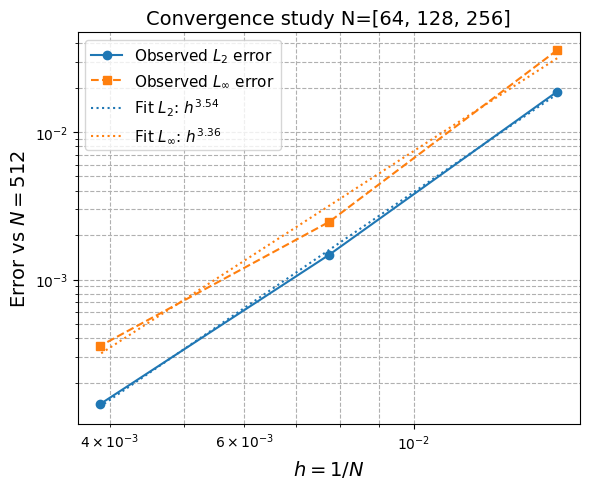

In [10]:
plt.figure(figsize=(6, 5))
plt.loglog(hs, err_L2,  'o-',  label='Observed $L_2$ error')
plt.loglog(hs, err_inf, 's--', label='Observed $L_\\infty$ error')
plt.loglog(hs, np.exp(coeffs_L2[1])  * hs ** coeffs_L2[0],
           ':', color='tab:blue',
           label=f'Fit $L_2$: $h^{{{coeffs_L2[0]:.2f}}}$')
plt.loglog(hs, np.exp(coeffs_inf[1]) * hs ** coeffs_inf[0],
           ':', color='tab:orange',
           label=f'Fit $L_\\infty$: $h^{{{coeffs_inf[0]:.2f}}}$')
plt.xlabel('$h = 1/N$', fontsize=14)
plt.ylabel('Error vs $N=512$', fontsize=14)
plt.title(f'Convergence study N={Ns_study}', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.savefig('p1c_convergence.png', dpi=150)
plt.show()